<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/07_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 7: Feature Engineering

This notebook builds the final feature dataset used by the machine learning notebooks. It combines the LM dictionary sentiment scores, FinBERT scores, topic-modeling outputs, divergence features, lag/trend features, and basic quarter information into one modeling-ready table.

Lag and trend features are created before the train/test split because they need each company’s full time-ordered sequence. Scaling is still fit only on the training years so the 2024 test year does not influence the feature ranges.

## What this notebook does

- Reads `584_earnings_topics.parquet` from Step 6.
- Sorts transcripts by ticker and earnings date.
- Creates lagged sentiment and trend features within each ticker.
- Creates prepared remarks vs Q&A divergence features.
- Adds topic-shift and selected topic-probability features.
- Scales numeric features with `MinMaxScaler` fit on training years only.
- Keeps sector as metadata so it can be one-hot encoded later in the modeling notebooks.
- Creates a simple language-based risk scorecard for interpretation.
- Saves the result as `584_earnings_features.parquet`.

## Output

- `584_earnings_features.parquet`

The output includes raw feature columns, scaled feature columns, metadata columns, `sector`, `sector_encoded`, and `risk_score`.

## Notes

- `TRAIN_YEARS = all_years[:-1]`
- `TEST_YEARS = [all_years[-1]]`
- `MinMaxScaler` is fit only on the training rows.
- `sector_encoded` is kept for reference only. It is not included in the scaled feature list because sector is categorical, not ordinal.
- The risk scorecard is a heuristic score for interpretation, not a trained predictive model.

In [ ]:
# =============================================================================
# STEP 7 — Feature Engineering
# Build the final modeling table with sentiment, topic, divergence, lag/trend,
# and scaled feature columns.
# =============================================================================

!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN  = f"{BASE_DIR}/Parquet/584_earnings_topics"
PARQUET_OUT = f"{BASE_DIR}/Parquet/584_earnings_features"

import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

from pyspark.sql import SparkSession

# Start a new Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

spark = SparkSession.builder \
    .master("local") \
    .appName("584_Feature_Engineering") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()

sc = spark.sparkContext

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df  = spark.read.parquet(PARQUET_IN)
pdf = df.toPandas()
pdf = pdf[pdf['qa_token_count'] > 0].reset_index(drop=True)
pdf = pdf.sort_values(['ticker', 'earnings_date']).reset_index(drop=True)

pdf['prev_prep_net_sentiment'] = pdf.groupby('ticker')['prep_net_sentiment'].shift(1)
pdf['prev_qa_negative_score']  = pdf.groupby('ticker')['qa_negative_score'].shift(1)
pdf['prev_finbert_negative']   = pdf.groupby('ticker')['prep_finbert_negative'].shift(1)

pdf['sentiment_trend']  = pdf['prep_net_sentiment'] - pdf['prev_prep_net_sentiment']
pdf['negativity_trend'] = pdf['prep_finbert_negative'] - pdf['prev_finbert_negative']

# Build lag and trend features within each ticker's time-ordered transcript history
lag_cols = [
    'prev_prep_net_sentiment',
    'prev_qa_negative_score',
    'prev_finbert_negative',
    'sentiment_trend',
    'negativity_trend'
]
pdf[lag_cols] = pdf[lag_cols].fillna(0)

print(f"Transcripts: {len(pdf)}")

all_years   = sorted(pdf['year'].unique().tolist())
TEST_YEARS  = [all_years[-1]]
TRAIN_YEARS = all_years[:-1]

train_mask = pdf['year'].isin(TRAIN_YEARS)

print(f"All years in dataset : {all_years}")
print(f"Training years       : {TRAIN_YEARS}")
print(f"Test year            : {TEST_YEARS}")

# ── Prepared remarks vs Q&A divergence features ─────────────────────────────
pdf['sentiment_divergence']   = (pdf['prep_net_sentiment']   - pdf['qa_net_sentiment']).round(6)
pdf['uncertainty_divergence'] = (pdf['qa_uncertainty_score'] - pdf['prep_uncertainty_score']).round(6)
pdf['tone_inconsistency']     = pdf['sentiment_divergence'].abs().round(6)

# Pull the quarter number from labels like "Q3_FY2024"
pdf['quarter_num'] = pdf['quarter'].str.extract(r'Q(\d)').astype(int)

# FinBERT divergence captures the gap between prepared remarks positivity and Q&A positivity
pdf['finbert_divergence'] = (pdf['prep_finbert_positive'] - pdf['qa_finbert_positive']).round(6)

# Keep a sector index for reference, but do not use it as a numeric model feature.
# One-hot encode the raw sector column instead
sector_index = {s: i for i, s in enumerate(sorted(pdf['sector'].unique()))}
pdf['sector_encoded'] = pdf['sector'].map(sector_index).fillna(0).astype(int)

FEATURE_COLS = [
    # LM dictionary — prepared remarks
    'prep_net_sentiment',
    'prep_negative_score',
    'prep_uncertainty_score',
    'prep_litigious_score',
    # LM dictionary — Q&A
    'qa_net_sentiment',
    'qa_negative_score',
    'qa_uncertainty_score',
    'qa_litigious_score',
    # Cross-section divergence features
    'sentiment_divergence',
    'uncertainty_divergence',
    'tone_inconsistency',
    # Topic modeling
    'qa_topic_shift',
    'qa_topic_2_prob',
    'qa_topic_3_prob',
    # Seasonality
    'quarter_num',
    # FinBERT sentiment — prepared remarks
    'prep_finbert_positive',
    'prep_finbert_negative',
    # FinBERT sentiment — Q&A
    'qa_finbert_positive',
    'qa_finbert_negative',
    # Prepared remarks vs Q&A FinBERT positivity gap
    'finbert_divergence',
    # Lag and trend features
    # NOTE: sector excluded from FEATURE_COLS — OHE applied in NB_08/NB_09
    'prev_prep_net_sentiment',
    'prev_qa_negative_score',
    'prev_finbert_negative',
    'sentiment_trend',
    'negativity_trend',
]

X_raw = pdf[FEATURE_COLS].copy()
X_raw['qa_topic_shift'] = X_raw['qa_topic_shift'].fillna(0.0)

# Fit the scaler on training years only
scaler     = MinMaxScaler()
scaler.fit(X_raw[train_mask])

print(f"\nScaler fit on {train_mask.sum()} train rows "
      f"({(~train_mask).sum()} test rows held out)")

X_scaled = pd.DataFrame(
    scaler.transform(X_raw),
    columns=[f"{c}_scaled" for c in FEATURE_COLS]
)

print("\nNormalized feature stats (train set only):")
print(X_scaled[train_mask].describe().round(4).to_string())

# ── Composite Risk Scorecard ──────────────────────────────────────────────────
# This is a simple scorecard for interpretation.
# The weights are hand-set to emphasize negative tone, uncertainty, tone gaps,
# and topic shift. This score is not trained as a predictive model.
# Weights sum to exactly 1.0.
RISK_WEIGHTS = {
    'prep_finbert_negative_scaled':   0.15,   # FinBERT: scripted negative tone
    'qa_finbert_negative_scaled':     0.15,   # FinBERT: unscripted Q&A negative tone
    'prep_negative_score_scaled':     0.12,   # LM dictionary: prepared negative
    'qa_negative_score_scaled':       0.10,   # LM dictionary: Q&A negative
    'tone_inconsistency_scaled':      0.10,   # Scripted vs unscripted tone gap
    'prep_uncertainty_score_scaled':  0.08,   # Management uncertainty language
    'qa_uncertainty_score_scaled':    0.08,   # Analyst uncertainty in Q&A
    'uncertainty_divergence_scaled':  0.08,   # Q&A more uncertain than prep?
    'qa_topic_shift_scaled':          0.08,   # Change in Q&A topic mix across calls
    'prep_litigious_score_scaled':    0.03,   # Legal/regulatory risk language
    'qa_litigious_score_scaled':      0.03,   # Legal language in Q&A
}
assert abs(sum(RISK_WEIGHTS.values()) - 1.0) < 1e-9, \
    f"Weights sum to {sum(RISK_WEIGHTS.values()):.4f}, must be 1.0"

risk_scores = pd.Series(0.0, index=X_scaled.index)
for col, weight in RISK_WEIGHTS.items():
    risk_scores += X_scaled[col] * weight

pdf['risk_score'] = risk_scores.round(4)

# ── Print scorecard ───────────────────────────────────────────────────────────
print(f"\n{'='*75}")
print("  COMPOSITE INVESTOR RISK SCORECARD")
print(f"  (Higher = more language-based risk signals detected)")
print(f"{'='*75}")
print(f"  {'Split':<6} {'Ticker':<8} {'Quarter':<12} {'Risk':>6}  {'Bar':<22}  {'Return':>8} {'Label'}")
print(f"  {'-'*70}")
for _, row in pdf.sort_values('risk_score', ascending=False).iterrows():
    bar       = '█' * int(row['risk_score'] * 40)
    direction = "▲" if row['pct_return_3d'] > 0 else "▼"
    split     = 'TRAIN' if row['year'] in TRAIN_YEARS else 'TEST '
    print(f"  [{split}] {row['ticker']:<8} {row['quarter']:12s}  "
          f"{row['risk_score']:.4f}  {bar:<22}  "
          f"{row['pct_return_3d']:>+7.2f}% {direction}")

# ── Build and save feature matrix ────────────────────────────────────────────
if 'sector' not in pdf.columns:
    pdf['sector'] = 'Unknown'
feature_matrix = pd.concat([
    pdf[['ticker', 'quarter', 'earnings_date', 'year', 'sector', 'pct_return_3d', 'return_label']],
    X_raw,
    X_scaled,
    pdf[['sector_encoded', 'risk_score']],  # sector_encoded kept as metadata
], axis=1)

print(f"\nFeature matrix shape: {feature_matrix.shape}")

for col in ['volume_on_date', 'window_days_used']:
    if col in pdf.columns:
        pdf[col] = pdf[col].astype('int64')

df_features = spark.createDataFrame(feature_matrix)
df_features.createOrReplaceTempView("earnings_features")

print("\nRisk scorecard via Spark SQL:")
spark.sql("""
    SELECT ticker, quarter, earnings_date,
        ROUND(prep_finbert_negative,    4) AS finbert_neg_prep,
        ROUND(qa_finbert_negative,      4) AS finbert_neg_qa,
        ROUND(prep_negative_score,      4) AS lm_neg_prep,
        ROUND(qa_uncertainty_score,     4) AS uncert_qa,
        ROUND(tone_inconsistency,       4) AS tone_gap,
        ROUND(qa_topic_shift,           4) AS topic_shift,
        ROUND(risk_score,               4) AS risk_score,
        ROUND(pct_return_3d,            2) AS return_pct,
        return_label
    FROM earnings_features
    ORDER BY risk_score DESC
""").show()

print("\nRisk tier classification:")
spark.sql("""
    SELECT ticker, quarter,
        ROUND(risk_score,    4) AS risk_score,
        ROUND(pct_return_3d, 2) AS actual_return,
        CASE
            WHEN risk_score > 0.50  THEN 'HIGH RISK'
            WHEN risk_score > 0.25  THEN 'MEDIUM RISK'
            ELSE                         'LOW RISK'
        END AS risk_tier,
        return_label
    FROM earnings_features
    ORDER BY risk_score DESC
""").show()

df_features.write.mode('overwrite').parquet(PARQUET_OUT)
print(f"\nSaved feature matrix to: {PARQUET_OUT}")
print("Verification rows:", spark.read.parquet(PARQUET_OUT).count())

spark.stop()
print("Spark session stopped.")

Streaming output truncated to the last 5000 lines.
  [TRAIN] FICO     Q4_FY2022     0.2473  █████████                +33.61% ▲
  [TEST ] MRK      Q2_FY2024     0.2472  █████████                 -0.04% ▼
  [TRAIN] COF      Q1_FY2021     0.2472  █████████                 +7.29% ▲
  [TRAIN] SYF      Q2_FY2023     0.2472  █████████                 -4.15% ▼
  [TRAIN] ZION     Q4_FY2022     0.2472  █████████                 -0.85% ▼
  [TRAIN] ETR      Q4_FY2022     0.2471  █████████                 -0.71% ▼
  [TRAIN] MSCI     Q3_FY2022     0.2471  █████████                 +5.76% ▲
  [TRAIN] HUM      Q3_FY2021     0.2471  █████████                 -1.08% ▼
  [TRAIN] PPL      Q3_FY2022     0.2471  █████████                 -1.19% ▼
  [TRAIN] VST      Q3_FY2022     0.2471  █████████                 +3.06% ▲
  [TEST ] HAS      Q4_FY2024     0.2471  █████████                 -0.74% ▼
  [TEST ] FDS      Q3_FY2024     0.2471  █████████                 -1.90% ▼
  [TRAIN] MSFT     Q1_FY2023     0.24

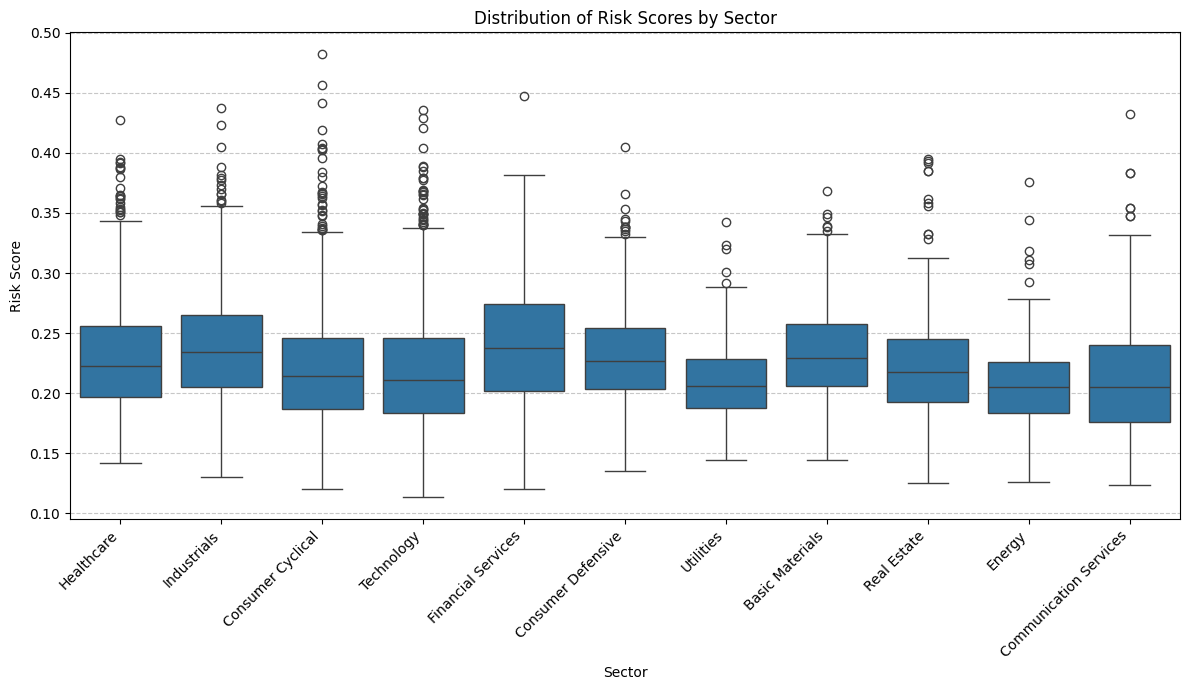

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to visualize risk score distribution by sector
plt.figure(figsize=(12, 7))
sns.boxplot(x='sector', y='risk_score', data=feature_matrix)
plt.title('Distribution of Risk Scores by Sector')
plt.xlabel('Sector')
plt.ylabel('Risk Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 5 Highest Risk Tickers

In [ ]:
top_5_risk_tickers = feature_matrix.sort_values(by='risk_score', ascending=False).head(5)
display(top_5_risk_tickers[['ticker', 'quarter', 'risk_score', 'pct_return_3d', 'return_label']])

,ticker,quarter,risk_score,pct_return_3d,return_label
5471,ROST,Q2_FY2022,0.4819,-5.0743,negative
5472,ROST,Q3_FY2022,0.4563,16.3730,positive
2790,GL,Q3_FY2021,0.4474,-1.7886,negative
3821,LKQ,Q2_FY2024,0.4416,4.8780,positive
5381,RHI,Q1_FY2024,0.4370,-2.0680,negative
